In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import KMeans model
from sklearn.cluster import KMeans
# Import feature scaling packages
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Import metrics
from sklearn.metrics import silhouette_score
# ignore warnigs if required
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Dataset/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
df['Age'].max()

70

#### Transform Gender Column

In [3]:
le = LabelEncoder()
df['Gender_Id'] = le.fit_transform(df['Gender'])

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_Id'],
      dtype='object')

### Features

In [5]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id']]

In [6]:
scaler = StandardScaler()
X_scale = scaler.fit_transform(X)
# X_scale

### Elbow Method - KMeans

In [7]:
k_range = range(1, 21)
error_rate = []

for i in k_range:
    kmeans = KMeans(n_clusters=i)
    kmeans.fit_predict(X_scale)
    error_rate.append(kmeans.inertia_) # centroid point calculation

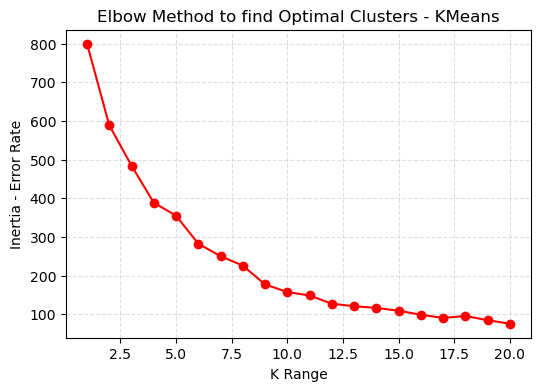

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(k_range, error_rate, marker='o', color='red')
plt.grid(linestyle='--', alpha=0.4)
plt.xlabel('K Range')
plt.ylabel('Inertia - Error Rate')
plt.title('Elbow Method to find Optimal Clusters - KMeans')
plt.show()

### Define Model

In [9]:
k = 4
model = KMeans(n_clusters=k)
clusters = model.fit_predict(X_scale)

In [10]:
df['cluster'] = clusters

In [11]:
sc = silhouette_score(X_scale, labels=clusters)
sc

0.29158907882696966

In [12]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Gender_Id', 'cluster'],
      dtype='object')

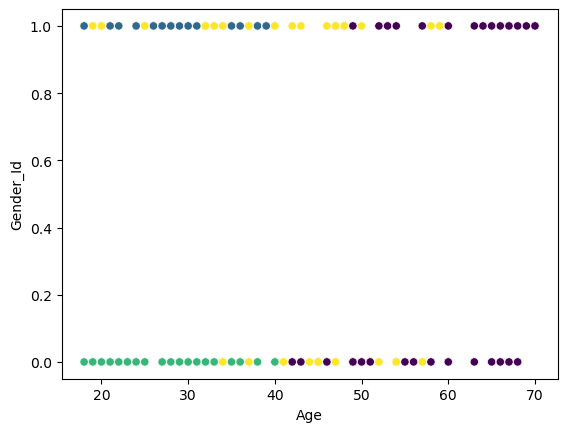

In [13]:
sns.scatterplot(data=df, x='Age', y='Gender_Id', c=df['cluster'])
plt.show()

In [14]:
import plotly.express as px

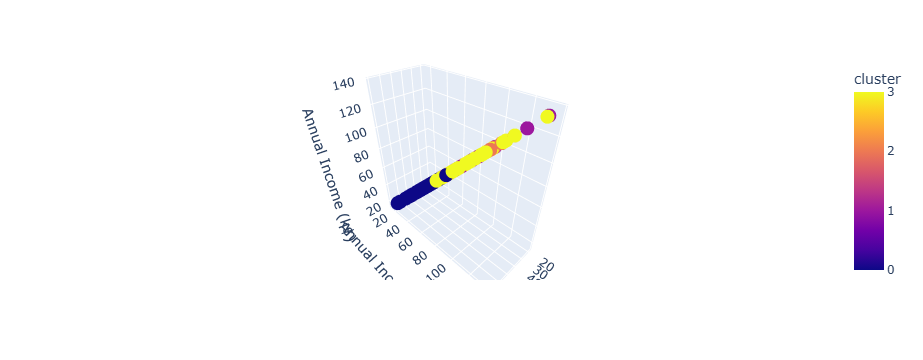

In [15]:
fig = px.scatter_3d(
    df,
    x='Age',
    y='Annual Income (k$)',
    z='Annual Income (k$)',
    color='cluster'
)
fig.show()

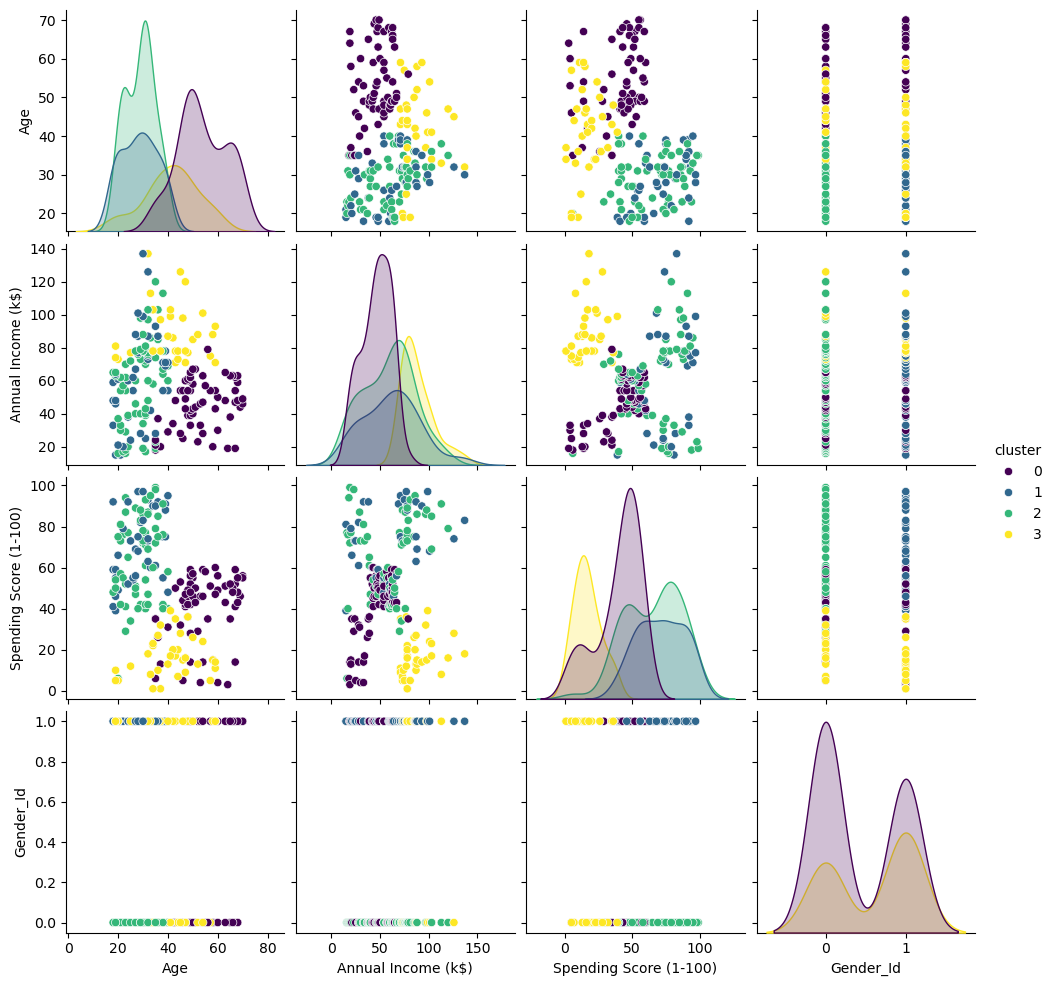

In [16]:
pair_plot = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id', 'cluster']]
sns.pairplot(
    pair_plot,
    hue='cluster',
    palette='viridis'
)

## PCA (Principle Component Analysis)

In [17]:
# import pca module
from sklearn.decomposition import PCA

In [18]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Id']

In [20]:
pca = PCA(n_components=(len(features)))

In [39]:
# calculation of co-variance
pca_scale = pca.fit_transform(X_scale)
# pca_scale

In [40]:
loadings = pd.DataFrame(
    pca.components_,
    index = features,
    columns = [f'PC{i+1}' for i in range(len(features))]
)
# loadings

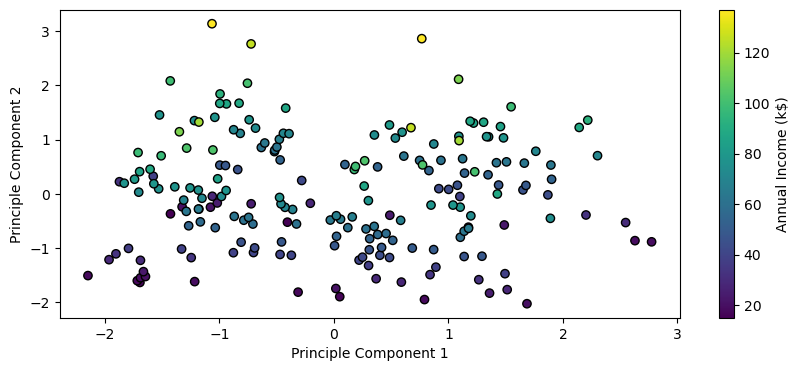

In [37]:
# X-axis -> Age, Gender
# Y-axis -> Annual Income, Spending Score

col = 'Annual Income (k$)'
plt.figure(figsize=(10, 4))
scatter = plt.scatter(pca_scale[:,0], pca_scale[:,1], edgecolor='black', c=df[col])
plt.colorbar(scatter, label=col)
plt.xlabel('Principle Component 1')
plt.ylabel('Principle Component 2')
plt.show()